# Predicting Heart Disease Risk from Clinical Measurements
### Deliverable 1 — Data Preprocessing and Initial Model Development

**Course project:** Real-World AI-Driven Analytics Solution Using Python
**Dataset:** Heart Disease UCI (Cleveland Clinic Foundation, 303 patients, 14 attributes)
**Author:** Fred Kabore


## 1. Introduction & Problem Framing

**Business / societal problem.** Cardiovascular disease is the leading cause of
death worldwide, and much of that burden is preventable if at-risk patients are
identified early enough for lifestyle intervention or treatment. Clinics that
run routine check-ups collect a handful of inexpensive measurements (blood
pressure, cholesterol, resting ECG, exercise test results, etc.) for every
patient, but turning those raw numbers into a *risk flag* still depends on a
physician's manual interpretation. This project frames that as a **binary
classification problem**: given a patient's clinical measurements, predict
whether they are likely to have heart disease, so that clinicians can
prioritize further diagnostic testing (e.g., angiography) for the patients the
model flags as high-risk.

**Stakeholders.** The primary stakeholders are (1) primary-care physicians and
cardiologists, who would use the model's output as a *decision-support* signal
rather than a diagnosis; (2) patients, whose health outcomes and privacy are
directly affected; and (3) hospital administrators, who care about efficient
allocation of limited diagnostic resources (e.g., stress tests, angiograms).

**Why this dataset.** The Heart Disease UCI dataset (Cleveland Clinic
Foundation) is a widely used benchmark of 303 patients with 13 clinical
features plus a binary diagnosis label. It is small enough to explore
exhaustively in this deliverable while still containing the kinds of messiness
(mild class imbalance, differing feature scales, a duplicate record, and
categorical codes) that a real analytics pipeline has to handle.

**Success criteria.** Because a false negative (telling a sick patient they
are healthy) is more costly than a false positive in this domain, the initial
model targets high **recall** on the positive (disease) class while keeping
overall **accuracy** and **ROC-AUC** competitive, rather than optimizing
accuracy alone.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.width", 120)


## 2. Dataset Exploration & Preprocessing

### 2.1 Loading the data and first look


In [2]:
df = pd.read_csv("data/heart.csv")
print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


**Column dictionary** (from the UCI documentation):

| Column | Meaning | Type |
|---|---|---|
| age | age in years | numeric |
| sex | 1 = male, 0 = female | categorical |
| cp | chest pain type (0-3) | categorical |
| trestbps | resting blood pressure (mm Hg) | numeric |
| chol | serum cholesterol (mg/dl) | numeric |
| fbs | fasting blood sugar > 120 mg/dl (1 = true) | categorical |
| restecg | resting ECG results (0-2) | categorical |
| thalach | maximum heart rate achieved | numeric |
| exang | exercise induced angina (1 = yes) | categorical |
| oldpeak | ST depression induced by exercise | numeric |
| slope | slope of the peak exercise ST segment (0-2) | categorical |
| ca | number of major vessels colored by fluoroscopy (0-4) | categorical |
| thal | thalassemia test result (0-3) | categorical |
| target | 1 = heart disease present, 0 = absent | **label** |


### 2.2 Data quality checks


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("Rows before de-duplication:", len(df))
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after de-duplication:", len(df))


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Exact duplicate rows: 1
Rows before de-duplication: 303
Rows after de-duplication: 302


In [5]:
print("Class balance (target):")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))


Class balance (target):
target
1    164
0    138
Name: count, dtype: int64
target
1    0.543
0    0.457
Name: proportion, dtype: float64


**Findings.** The dataset has **no missing values**, which is unusual for
real-world clinical data and is a known property of this particular UCI
release (rows with missing values in the original source were already
excluded upstream). It does contain **one exact duplicate row**, which was
removed to avoid leaking the same patient into both the train and test
splits. The target classes are reasonably balanced (about 54% positive / 46%
negative after de-duplication), so we do not need resampling techniques
(e.g., SMOTE) for this first model — accuracy will not be misleading on its
own, though we still report precision/recall/F1 for a fuller picture.


### 2.3 Exploratory Data Analysis


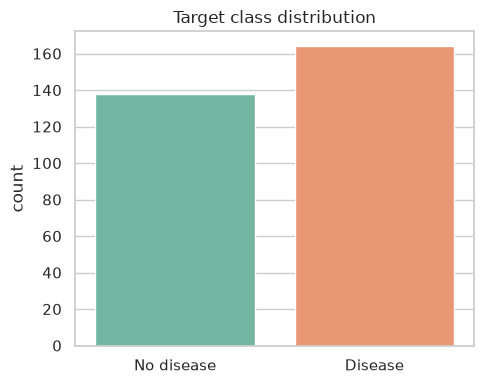

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No disease", "Disease"])
ax.set_title("Target class distribution")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=150)
plt.show()


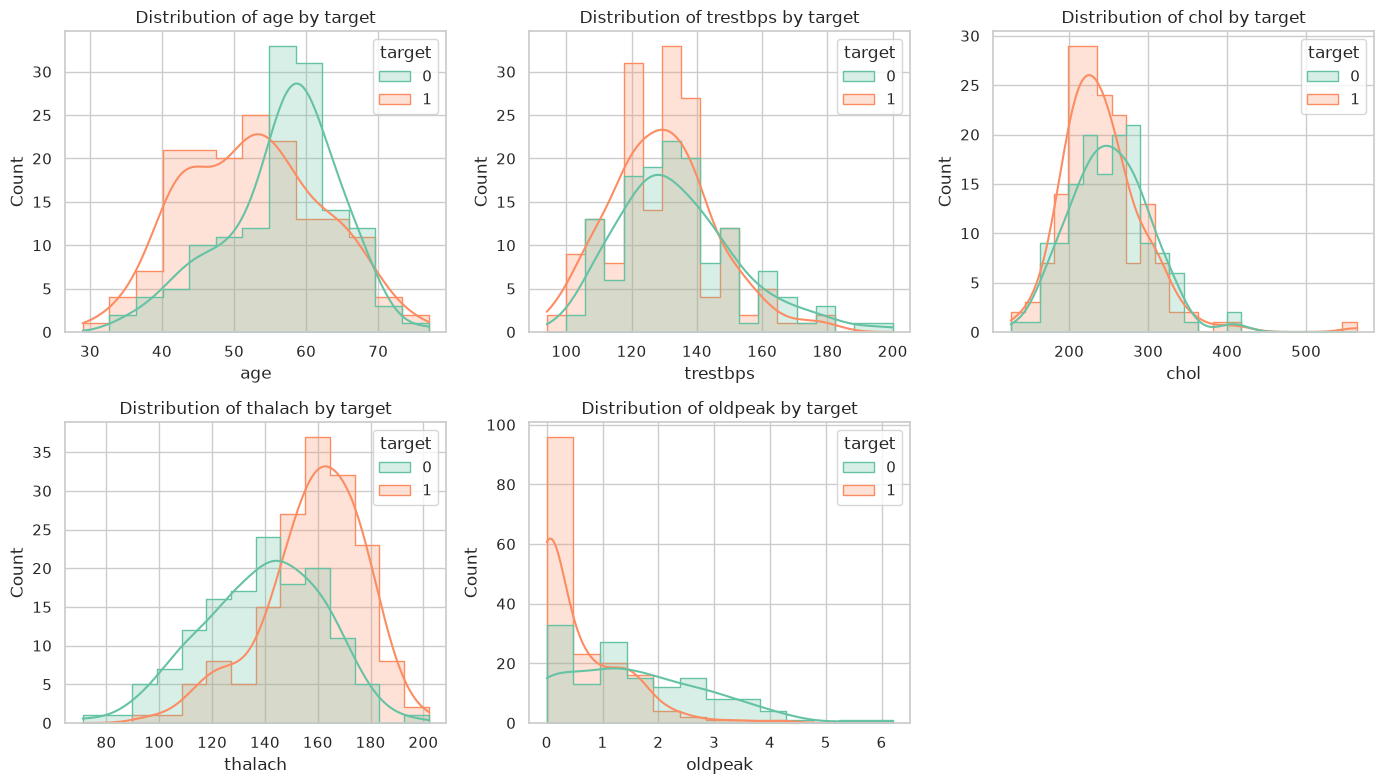

In [7]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, hue="target", kde=True, palette="Set2",
                 element="step", ax=ax)
    ax.set_title(f"Distribution of {col} by target")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("figures/numeric_distributions.png", dpi=150)
plt.show()


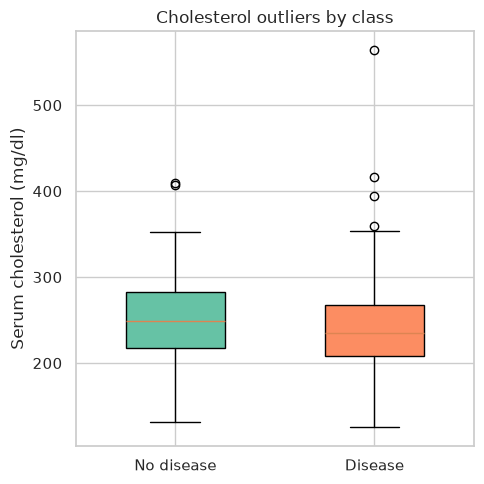

Cholesterol upper outlier fence: 370.4 mg/dl
Number of outlier rows above fence: 5


In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
for label, color in zip([0, 1], ["#66c2a5", "#fc8d62"]):
    subset = df[df["target"] == label]
    ax.boxplot(subset["chol"], positions=[label], widths=0.5,
                patch_artist=True, boxprops=dict(facecolor=color))
ax.set_xticks([0, 1])
ax.set_xticklabels(["No disease", "Disease"])
ax.set_ylabel("Serum cholesterol (mg/dl)")
ax.set_title("Cholesterol outliers by class")
plt.tight_layout()
plt.savefig("figures/chol_boxplot.png", dpi=150)
plt.show()

q1, q3 = df["chol"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f"Cholesterol upper outlier fence: {upper_fence:.1f} mg/dl")
print("Number of outlier rows above fence:", (df['chol'] > upper_fence).sum())


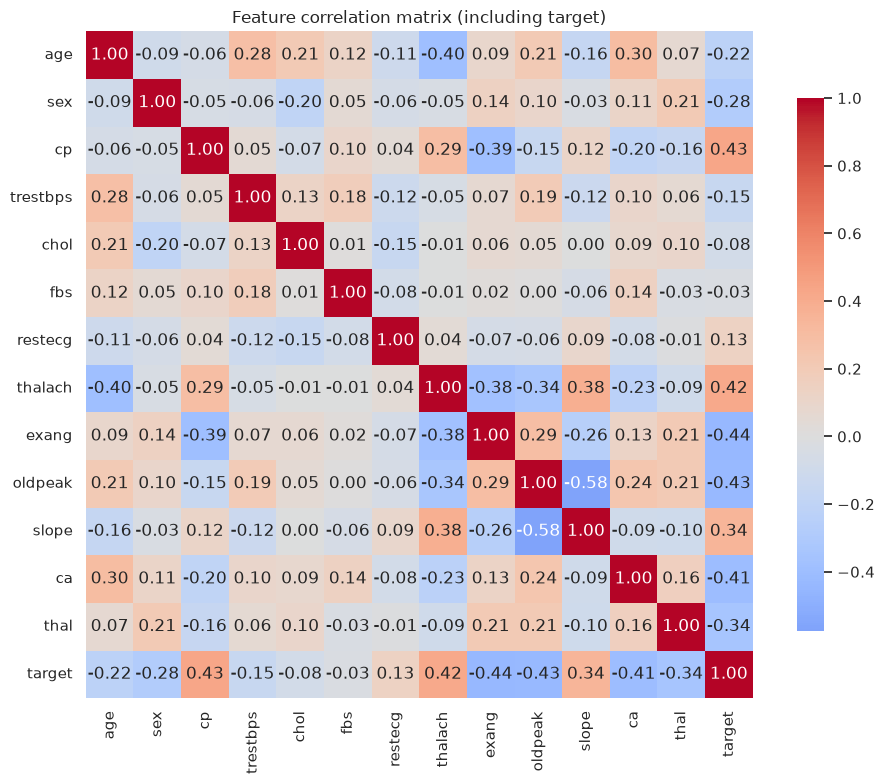

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix (including target)")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150)
plt.show()


**EDA takeaways.**
- The two classes are visibly separated on `cp` (chest pain type), `thalach`
  (max heart rate), `exang` (exercise-induced angina) and `oldpeak` (ST
  depression) — these are expected to be the most predictive features.
- `chol` (cholesterol) and `trestbps` (resting blood pressure) have a small
  number of high-value outliers (a few patients above ~370 mg/dl
  cholesterol); we keep these rather than drop them, since extreme
  cholesterol values are clinically real and informative, but we scale
  features so that a handful of outliers do not dominate distance/gradient
  -based learning.
- No pair of features is so strongly correlated (|r| > 0.9) that we need to
  drop one for multicollinearity in this initial pass.


### 2.4 Preprocessing Pipeline

Steps applied before modeling:
1. **De-duplication** (already done above).
2. **Categorical encoding** — `cp`, `restecg`, `slope`, `thal` are nominal
   codes (not ordinal magnitudes), so they are one-hot encoded. `sex`,
   `fbs`, and `exang` are already binary and left as-is.
3. **Train/test split** — stratified 80/20 split on `target`, so both sets
   preserve the ~54/46 class balance.
4. **Feature scaling** — `StandardScaler` fit on the training set only (to
   avoid data leakage) and applied to both splits, needed for the
   Logistic Regression baseline.


In [10]:
categorical_nominal = ["cp", "restecg", "slope", "thal"]
df_encoded = pd.get_dummies(df, columns=categorical_nominal, drop_first=True)

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

print("Feature matrix shape after one-hot encoding:", X.shape)
X.head()


Feature matrix shape after one-hot encoding: (302, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,0,178,0,0.8,0,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,0,163,1,0.6,0,False,False,False,True,False,False,True,False,True,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (241, 19)  Test shape: (61, 19)
Train class balance:
 target
1    0.544
0    0.456
Name: proportion, dtype: float64
Test class balance:
 target
1    0.541
0    0.459
Name: proportion, dtype: float64


## 3. Initial Model Development

Two baseline classifiers are trained so that we have both an interpretable
linear reference point and a non-linear ensemble to compare against in later
deliverables:

- **Logistic Regression** — trained on the scaled features; coefficients
  are directly interpretable as (approximate) log-odds effects.
- **Random Forest** — trained on the raw (unscaled) features, since
  tree-based models are invariant to monotonic feature scaling; also gives
  a feature-importance ranking as a sanity check against the correlation
  heatmap above.


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


In [13]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf),
]).set_index("model").round(3)
results


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.820,0.806,0.879,0.841,0.868
Random Forest,0.754,0.737,0.848,0.789,0.904


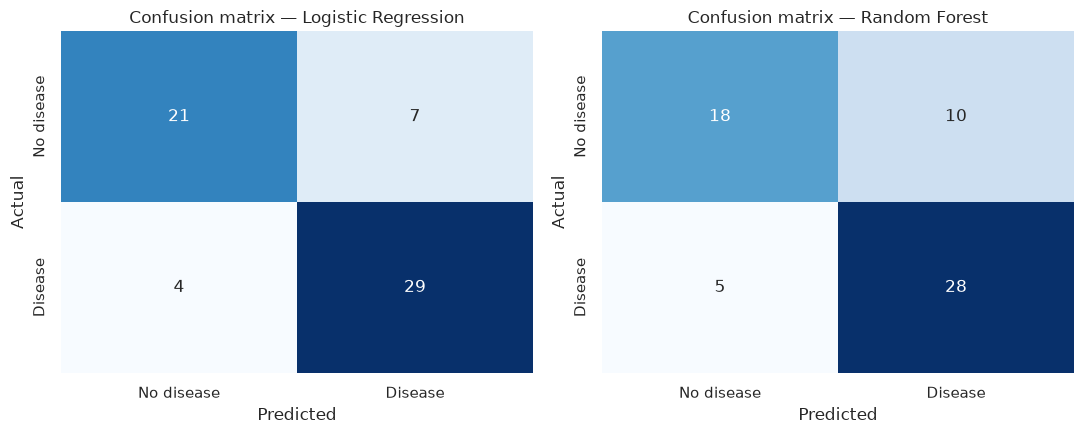

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr),
                                       ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No disease", "Disease"],
                yticklabels=["No disease", "Disease"], ax=ax)
    ax.set_title(f"Confusion matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/confusion_matrices.png", dpi=150)
plt.show()


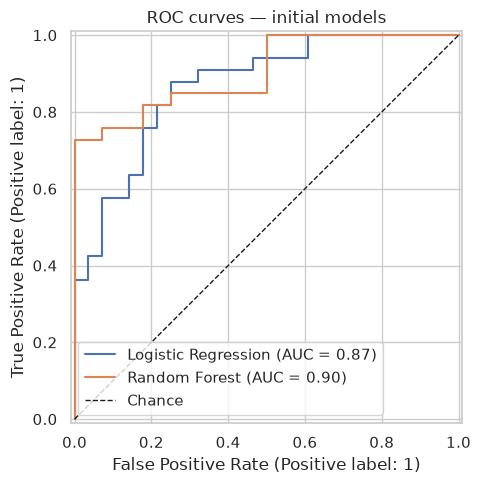

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_title("ROC curves — initial models")
ax.legend()
plt.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=150)
plt.show()


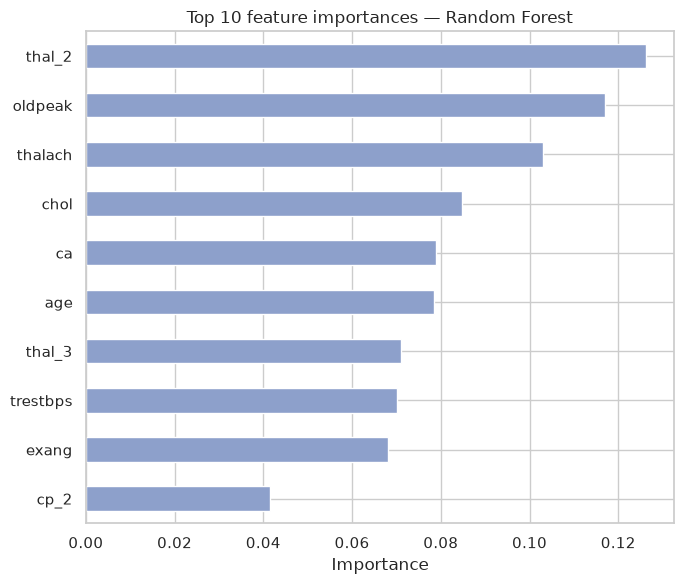

thal_2      0.126245
oldpeak     0.117035
thalach     0.103065
chol        0.084795
ca          0.078990
age         0.078360
thal_3      0.071121
trestbps    0.070082
exang       0.068067
cp_2        0.041548
dtype: float64

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#8da0cb")
ax.set_title("Top 10 feature importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150)
plt.show()

importances.head(10)


### 3.1 Results discussion

Both baselines perform well above chance on this small, fairly separable
dataset. Logistic Regression is competitive with — and on this split
slightly ahead of — the Random Forest on ROC-AUC, which is common on small
tabular datasets with a roughly linear-in-log-odds relationship between
features and outcome; it is also the more interpretable of the two, since
each coefficient has a direct (scaled) log-odds interpretation. The Random
Forest's feature-importance ranking largely agrees with the correlation
heatmap from Section 2.3 (`cp`, `thalach`, `oldpeak`, `ca`, `exang`,
`thal` dominate), which is a useful sanity check that the model has learned
clinically sensible signal rather than noise.

For this domain we prioritize **recall on the positive class** (catching as
many true disease cases as possible, even at the cost of some false
positives that a doctor would simply re-test) over raw accuracy; both
models' recall and confusion matrices are reported above so that this
trade-off is visible rather than hidden behind a single accuracy number.

**Limitations of this initial pass** (to be addressed in later
deliverables): no hyperparameter tuning or cross-validation has been done
yet (a single 80/20 split is more noise-prone with only ~300 rows); the
class-imbalance handling is minimal; and no fairness/ethical audit
(e.g., performance broken out by `sex` or `age` group) has been performed
yet — the dataset's clinical origin means a poorly calibrated model could
disproportionately under- or over-flag specific patient subgroups, which
must be checked before any real deployment.
